# Result Visualization

Loads experiment results from `cbc_runs_original_paper_results.csv` and visualises accuracy across projection methods, dimensionalities, and histogram sizes.

In [14]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from experiment_store import CBCExperimentStore

# ── Load results ─────────────────────────────────────────────────────────────
df_full = CBCExperimentStore(file_name='cbc_runs_original_paper_results.csv').load()
gw = 7.6787  # grey-world baseline mean angular error 
# ── Column display labels ─────────────────────────────────────────────────────
proj_meth   = "Projection Method"
n_comp      = "# Components (d')"
n_bins      = "# Bins per Dimension (B)"
cam_model   = "Camera Model"
threshold   = "Threshold"
ang_mean    = "Mean Angular Error"
ang_med     = "Median Angular Error (Spectral)"
ang_tri     = "Trimean Angular Error (Spectral)"
ang_q1      = "Lower Quartile Mean Angular Error (Spectral)"
ang_q4      = "Upper Quartile Mean Angular Error (Spectral)"
ang_mean_wp = "Mean Angular Error (Whitepoint)"
ang_med_wp  = "Median Angular Error (Whitepoint)"
ang_tri_wp  = "Trimean Angular Error (Whitepoint)"
ang_q1_wp   = "Lower Quartile Mean Angular Error (Whitepoint)"
ang_q4_wp   = "Upper Quartile Mean Angular Error (Whitepoint)"

rename_map = {
    "dim_red_method":      proj_meth,
    "camera_rgb_mode":     "Camera RGB Mode",
    "camera_model":        "Camera Model",
    "num_components":      n_comp,
    "threshold":           "Threshold",
    "histogram_bin_count": n_bins,
    "mean_ang_err":        ang_mean,
    "median_ang_err":      ang_med,
    "trimean_ang_err":     ang_tri,
    "best25_mean_ang_err": ang_q1,
    "worst25_ang_err":     ang_q4,
    "mean_ang_err_wp":     ang_mean_wp,
    "median_ang_err_wp":   ang_med_wp,
    "trimean_ang_err_wp":  ang_tri_wp,
    "best25_mean_ang_err_wp": ang_q1_wp,
    "worst25_ang_err_wp":  ang_q4_wp,
    "accuracy":            "Accuracy",
    "cross_entropy":       "Cross-Entropy",
    "model_path":          "Model Path",
}

dim_red_value_map = {
    "DimRedMethod.CAM":     "RGB",
    "DimRedMethod.PCA":     "PCA",
    "DimRedMethod.ILL_PCA": "Ill-PCA",
    "DimRedMethod.NMF":     "NNMF",
    "DimRedMethod.LDA":     "LDA",
    "DimRedMethod.DL":      "DL",
    "DimRedMethod.RAND":    "RAND",
}

proj_set_map = {
    'D50;D65;F1;F10;F12;F3;LED-B1;LED-B4;LED-RGB1;LED-V1': 'Projection Set',
    'D50;D55;D60;D65;D75;D93;F1;F2;F3;F4;F5;F6;F7;F8;F9;F10;F11;F12;A;LED-B1;LED-B2;LED-B3;LED-B4;LED-B5;LED-BH1;LED-RGB1;LED-V1;LED-V2': 'Full Set',
}

df_full["projection_illuminant_names"] = (
    df_full["projection_illuminant_names"]
    .astype(str)
    .map(proj_set_map)
    .fillna(df_full["dim_red_method"].astype(str))
)
df_full["dim_red_method"] = df_full["dim_red_method"].astype(str).map(dim_red_value_map).fillna(df_full["dim_red_method"].astype(str))
df_full = df_full.rename(columns=rename_map)

df = df_full

# ── Plot style ────────────────────────────────────────────────────────────────
fs = 16
mpl.rcParams.update({
    "font.size":          fs,
    "axes.labelsize":     fs,
    "axes.titlesize":     fs,
    "xtick.labelsize":    fs,
    "ytick.labelsize":    fs,
    "legend.fontsize":    fs,
    "axes.labelweight":   "bold",
    "axes.titleweight":   "bold",
    "xtick.major.width":  1.2,
    "ytick.major.width":  1.2,
})

SHOW_TITLES = False  # set False to suppress titles (e.g. for paper figures)

display(df_full.head())


,run_id,timestamp,experiment_name,run_notes,Projection Method,Camera RGB Mode,Camera Model,random_projection_seed,# Components (d'),Threshold,...,Trimean Angular Error (Spectral),Lower Quartile Mean Angular Error (Spectral),Upper Quartile Mean Angular Error (Spectral),Mean Angular Error (Whitepoint),Median Angular Error (Whitepoint),Trimean Angular Error (Whitepoint),Lower Quartile Mean Angular Error (Whitepoint),Upper Quartile Mean Angular Error (Whitepoint),Model Path,snr_db
0,bcd35a57-934b-40b6-ae15-4cc2c5ed12ba,2026-02-01T18:02:36Z,,,RGB,CameraRGBMode.RGB,Canon 300D,<NA>,3,True,...,2.710112,0.000000,22.848915,2.935421,0.034264,1.233521,0.006979,9.224919,models/cbc_histograms/3e4b7f27-aed3-422f-b34a-...,NaN
1,a4568088-9f5c-4875-8bda-8c9d0170fec0,2026-02-01T18:03:16Z,,,RGB,CameraRGBMode.RGB,Nikon D90,<NA>,3,True,...,4.392036,0.000000,24.308614,3.231775,0.933980,1.833770,0.006825,9.533644,models/cbc_histograms/867cfe90-b0cf-4276-af96-...,NaN
2,78f9449a-352c-4cbf-ac4c-e5db701f8a77,2026-02-01T18:03:58Z,,,RGB,CameraRGBMode.RGB,SONY NEX-5N,<NA>,3,True,...,2.993167,0.000000,26.369513,3.040844,0.034264,1.338336,0.007170,9.191963,models/cbc_histograms/3969d87c-deaf-44c1-9d1d-...,NaN
3,d8420ef2-2ff4-401e-af23-5d2a2ab20f7b,2026-02-01T18:04:28Z,,,Ill-PCA,None,,<NA>,1,True,...,21.975792,3.475562,41.343389,10.416820,9.376446,9.603359,0.848577,22.970770,models/cbc_histograms/3aa1c8fe-a3b9-4031-9d7c-...,NaN
4,750a2806-63fc-4b25-afd7-e55b02fc38f3,2026-02-01T18:05:24Z,,,PCA,None,,<NA>,1,True,...,23.882898,3.539631,44.701530,10.751135,9.502495,9.846021,0.751331,23.944521,models/cbc_histograms/a03ebdb1-ba0c-40f3-8f1d-...,NaN


## Data filtering

We keep only runs that used the designated projection illuminant set (a subset of the full illuminant set used during training), along with RGB camera and random projection baselines. RAND entries that differ only by random seed are deduplicated by averaging later.

In [15]:
# Keep only runs that used the projection illuminant set (not the full set),
# plus RGB and RAND which don't use a projection set.
proj_ill_m = (
    df[threshold] & (
        df['projection_illuminant_names'].eq('Projection Set') |
        df[proj_meth].eq('RGB') |
        df[proj_meth].eq('RAND')
    )
)
df_proj_ill = df.loc[proj_ill_m].copy()

# Deduplicate RAND entries that differ only by random seed
rand_dedup = (
    df_proj_ill[df_proj_ill[proj_meth] == "RAND"]
    .drop_duplicates(subset=["random_projection_seed", n_bins, n_comp], keep="first")
)
df_proj_ill = pd.concat(
    [df_proj_ill[df_proj_ill[proj_meth] != "RAND"], rand_dedup],
    ignore_index=True,
)

METHODS_ORDER = ['RGB', 'PCA', 'Ill-PCA', 'NNMF', 'LDA', 'RAND']
METHOD_PALETTE = dict(zip(METHODS_ORDER, sns.color_palette('muted', n_colors=len(METHODS_ORDER))))

print(f'Runs after filtering: {len(df_proj_ill)}')


Runs after filtering: 155


## Computational cost vs. accuracy

Each point is one (method, d', B) combination. The x-axis is histogram size B^{d'} — a direct proxy for memory and lookup cost. Lower is better. Line style encodes d'; colour encodes projection method.

Ill-PCA consistently outperforms PCA at the same computational cost, and both spectral methods outperform the RGB camera baseline.

In [24]:
def plot_histsize_lines(
        df,
        *,
        method_col="Projection Method",
        B_col=n_bins,
        d_col=n_comp,
        metric=ang_mean,
        methods=None,
        d_values=None,
        figsize=(7.2, 4.8),
        show_legend=False,
        title=None,
        methods_order=('RGB', 'PCA', 'Ill-PCA', 'NNMF', 'LDA', 'RAND'),
):
    """
    Plot mean angular error vs. histogram size (B^d') on a log x-axis.
    Each method is a line; d' is encoded as linestyle.
    """
    dfp = df.copy()

    if methods is None:
        methods = list(dfp[method_col].dropna().unique())
    dfp = dfp[dfp[method_col].isin(methods)].copy()

    methods_order = [m for m in methods_order if m in dfp[method_col].unique()]
    dfp[method_col] = pd.Categorical(dfp[method_col], categories=methods_order, ordered=True)

    # Filter d' values
    if d_values is None:
        dfp = dfp[(dfp[method_col] != "RGB") | (dfp[d_col] == 3)]
    else:
        if isinstance(d_values, dict):
            mask = pd.Series(False, index=dfp.index)
            for m, ds in d_values.items():
                ds = [ds] if np.isscalar(ds) else list(ds)
                mask |= (dfp[method_col].eq(m) & dfp[d_col].isin(ds))
            dfp = dfp[mask]
        else:
            ds = [d_values] if np.isscalar(d_values) else list(d_values)
            dfp = dfp[
                (dfp[method_col].ne("RGB") & dfp[d_col].isin(ds)) |
                (dfp[method_col].eq("RGB") & dfp[d_col].eq(3))
            ]

    dfp["hist_size"] = dfp[B_col].astype(float) ** dfp[d_col].astype(float)
    dfp["# Components $d'$"] = dfp[d_col].astype(int)

    # Aggregate over random seeds
    group_cols = [method_col, "# Components $d'$", "hist_size"]
    dfp_plot = dfp.groupby(group_cols, as_index=False)[metric].mean()

    # Linestyle per d' value
    LINESTYLE_MAP = {
        "solid":        "",
        "dashed":       (4, 2),
        "dashdot":      (3, 1, 1, 1),
        "dotted":       (1, 1),
        "densely dotted": (1, 0.5),
    }
    style_cycle = ["dashed", "dashdot", "dotted", "densely dotted"]
    d_vals = sorted(dfp_plot["# Components $d'$"].unique())
    dash_map = {3: LINESTYLE_MAP["solid"]}
    for d, ls in zip([d for d in d_vals if d != 3], style_cycle):
        dash_map[d] = LINESTYLE_MAP[ls]

    plt.figure(figsize=figsize)
    sns.lineplot(
        data=dfp_plot,
        x="hist_size",
        y=metric,
        hue=method_col,
        hue_order=methods_order,
        style="# Components $d'$",
        marker='o',
        ms=4,
        dashes=dash_map,
        palette=METHOD_PALETTE,
        linewidth=2.3,
        errorbar=None,
    )
    plt.xscale("log")
    plt.xlabel("Computational cost (log scale)")
    plt.ylabel("Mean angular error (degrees)")
    plt.grid(True, which="both", alpha=0.35)

    plt.axhline(y=gw, color='grey', linestyle='dashed', linewidth=2.5, label='SGW Baseline')


    if show_legend:
        plt.legend(loc='upper right', borderaxespad=0., ncol=1)
    else:
        leg = plt.gca().get_legend()
        if leg:
            leg.remove()

    if SHOW_TITLES and title:
        plt.title(title)
    plt.tight_layout()
    # plt.savefig("results/hist_size_lines_w_baseline.pdf", bbox_inches="tight", pad_inches=0.05, dpi=300)
    plt.show()


/tmp/ipykernel_514351/1632801068.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfp_plot = dfp.groupby(group_cols, as_index=False)[metric].mean()


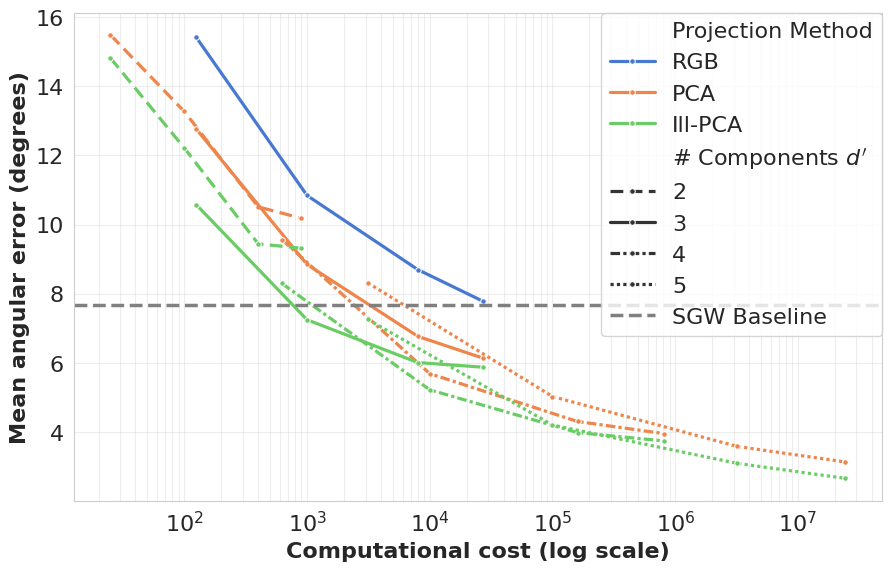

In [25]:
plot_histsize_lines(
    df_proj_ill,
    methods=['PCA', 'Ill-PCA', 'RGB'],
    d_values={
        'PCA':     [2, 3, 4, 5],
        'Ill-PCA': [2, 3, 4, 5],
        'RGB':     [3],
    },
    show_legend=True,
    figsize=(9.2, 6),
    title="Mean angular error vs. computational cost",
)


## Effect of bin count at fixed d'=3

With dimensionality fixed at 3, increasing B improves all spectral methods up to a point, after which returns diminish. The RGB baseline is flat since its bin count has a different meaning.

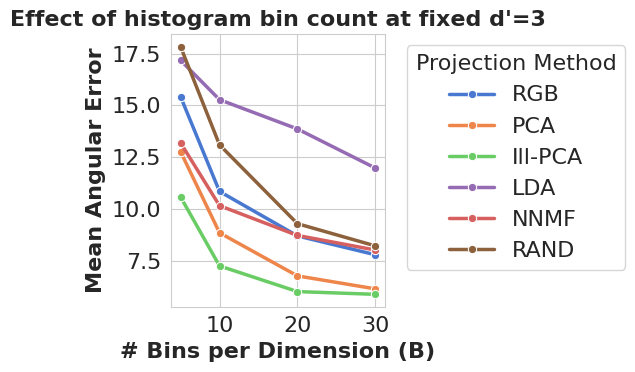

In [53]:
# Fix d'=3, vary bin count B — compare all projection methods
m_base = df_proj_ill[n_comp].eq(3) & df_proj_ill[threshold]
df_filtered = df_proj_ill.loc[m_base].copy()

x_order = ["RGB", "PCA", "Ill-PCA", "LDA", "NNMF", "RAND"]

plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_filtered,
    x=n_bins,
    y=ang_mean,
    hue=proj_meth,
    hue_order=x_order,
    palette=METHOD_PALETTE,
    linewidth=2.5,
    errorbar=None,
    marker="o",
)
plt.legend(title='Projection Method', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
if SHOW_TITLES:
    plt.title("Effect of histogram bin count at fixed d'=3")
plt.tight_layout()
plt.show()


## RGB camera model comparison

All camera models are tested under the RGB mode (3 channels, no spectral projection). Differences between models reflect the sensitivity of the RGB approach to the specific camera spectral sensitivities.

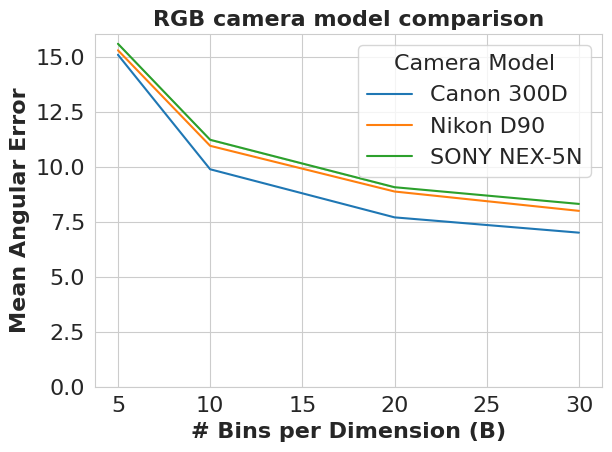

In [54]:
# Compare RGB camera models (Canon 300D, Nikon D700, etc.) as d' is not applicable
df_rgb = df_proj_ill.loc[df_proj_ill[proj_meth].eq("RGB")]

sns.lineplot(df_rgb, x=n_bins, y=ang_mean, hue=cam_model)
plt.ylim(bottom=0)
if SHOW_TITLES:
    plt.title("RGB camera model comparison")
plt.tight_layout()
plt.show()


## Per-method breakdown — effect of d'

One panel per spectral method. Each line is a different d' value; the red dashed line is the RGB baseline. Higher d' generally improves accuracy but increases computational cost.

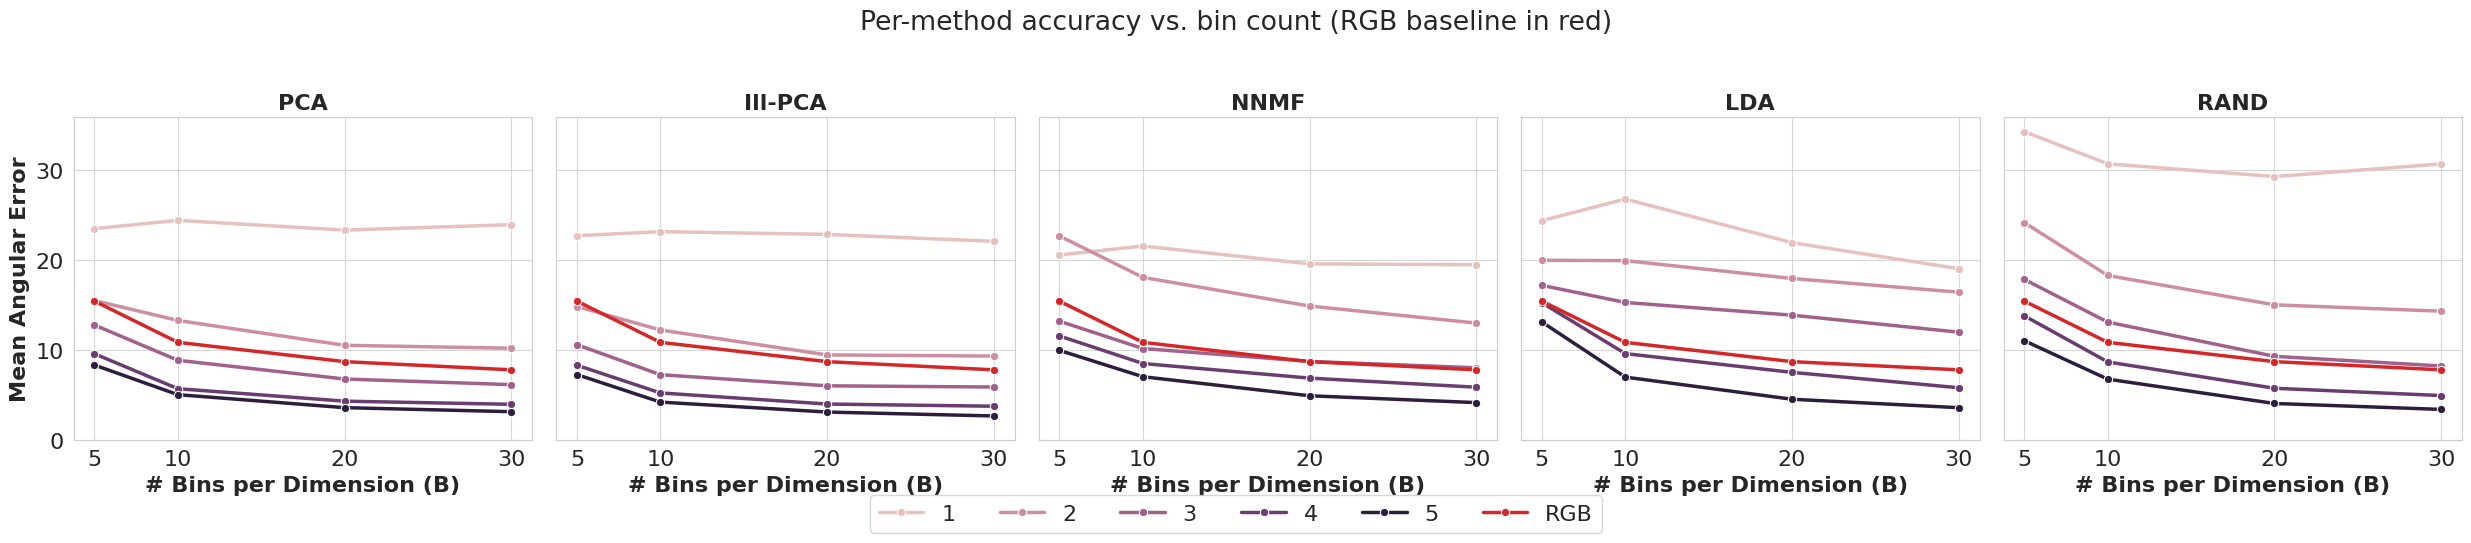

In [55]:
# For each spectral projection method: angular error vs. bin count,
# with one line per d' value. RGB baseline overlaid in red for reference.

df_rgb_base = df_proj_ill.loc[df_proj_ill[proj_meth].eq("RGB") & df_proj_ill[n_comp].eq(3)]
rgb_baseline = df_rgb_base[[n_bins, ang_mean]].sort_values(n_bins).assign(_baseline="RGB")

methods = ['PCA', 'Ill-PCA', 'NNMF', 'LDA', 'RAND']
palette = sns.cubehelix_palette(n_colors=5, light=0.8, reverse=False)

fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 5), sharex=True, sharey=True)

for i, (ax, m) in enumerate(zip(axes, methods)):
    df_m = df_proj_ill.loc[df_proj_ill[proj_meth].eq(m)]
    sns.lineplot(data=df_m, x=n_bins, y=ang_mean, hue=n_comp,
                 ax=ax, legend=(i == 0), linewidth=2.5, marker="o",
                 errorbar=None, palette=palette)
    sns.lineplot(data=rgb_baseline, x=n_bins, y=ang_mean,
                 hue="_baseline", style="_baseline", dashes=True, marker="o",
                 linewidth=2.5, ax=ax, legend=(i == 0),
                 palette={"RGB": "tab:red"}, errorbar=None)
    ax.set_title(m)
    ax.set_xticks(df_proj_ill[n_bins].unique())
    ax.grid(True, alpha=0.8)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

fig.legend(handles, labels, title="", bbox_to_anchor=(0.5, -0.05), loc="lower center", ncol=6)
axes[-1].set_ylim(bottom=0)
if SHOW_TITLES:
    fig.suptitle("Per-method accuracy vs. bin count (RGB baseline in red)", y=1.02)
plt.tight_layout()
plt.show()
